# Isolation Forest Anomaly Detection

This notebook uses an **Isolation Forest** model to detect anomalies in spectra data, following the same workflow as `knn_5_euclidean.ipynb`.

**Core idea:**
- An Isolation Forest detects anomalies by randomly partitioning the feature space using decision trees
- <span style="color:green"><strong>A Normal samples require many partitions to isolate (they sit in dense regions)</strong></span>
- <span style="color:orange"><strong>Anomalous samples require very few partitions to isolate (they sit in sparse, outlying regions)</strong></span>
- The **anomaly score** is based on the average path length across all trees — shorter path = more anomalous

Interpretation of Anomaly Score
- (a) if anomaly score is very close to 1, then it is definitely an anomaly
- (b) if anomaly score is much smaller than 0.5, then it is quite safe to be regarded as normal instances
- (c) if anomaly score is ≈0.5, then the sample does not really have any distinct anomaly.

**Advantage over KNN:** Isolation Forest does not compute pairwise distances, making it much faster on high-dimensional data like the 535 wavelength features here.

**Goal:** Evaluate whether the model can correctly identify `ambient_spectra.csv` particles as anomalies.

## 1. Hyperparameters

All settings are defined here so you can experiment without hunting through the code.

| Parameter | Description |
|-----------|-------------|
| `N_ESTIMATORS` | Number of isolation trees. More trees = more stable scores but slower. Default is 100 |
| `MAX_SAMPLES` | Number of training samples drawn to build each tree. `'auto'` uses min(256, n_samples). Smaller = faster but noisier |
| `MAX_FEATURES` | Fraction of features used to build each tree. Lower values add randomness and can improve generalization |
| `THRESHOLD_PERCENTILE` | Percentile of normal training scores used as the decision boundary. Scores below this are flagged as anomalies (lower score = more anomalous in Isolation Forest) |

In [5]:
# ── Tune these values to experiment with the model ──────────────────────────

N_ESTIMATORS        = 100    # number of isolation trees
MAX_SAMPLES         = 'auto' # samples per tree: 'auto' or an integer (e.g. 256)
MAX_FEATURES        = 1.0    # fraction of features per tree: 1.0 = all features
THRESHOLD_PERCENTILE = 5     # bottom percentile of normal scores used as threshold
                             # (lower score = more anomalous, so we cut from the bottom)

# ─────────────────────────────────────────────────────────────────────────────

## 2. Imports

Loading all libraries needed for the Isolation Forest model, evaluation metrics, and plotting.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest                # Isolation Forest model
from sklearn.metrics import (                               # evaluation tools
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 3. Load Data

- `all_spectra.csv` → **normal** particles. The model trains exclusively on these.
- `ambient_spectra.csv` → **anomaly** particles. Only used at evaluation time — the model never sees them during training.

Only the wavelength intensity columns are used as features. The `polymer` label column is dropped.

In [7]:
# Load both datasets; the unnamed first column is the row index
all_spectra     = pd.read_csv('../data/all_spectra.csv',     index_col=0)
ambient_spectra = pd.read_csv('../data/ambient_spectra.csv', index_col=0)

# Identify the label column and keep only wavelength columns as features
label_col   = 'polymer'
wavelengths = [c for c in all_spectra.columns if c != label_col]

# Feature matrices — rows = samples, columns = wavelength intensities
X_normal  = all_spectra[wavelengths].values      # shape: (1215, 535)
X_anomaly = ambient_spectra[wavelengths].values  # shape: (55, 535)

print(f'Normal samples  : {X_normal.shape}')
print(f'Anomaly samples : {X_anomaly.shape}')
print(f'Features (wavelengths): {X_normal.shape[1]}')

Normal samples  : (1215, 535)
Anomaly samples : (55, 535)
Features (wavelengths): 535


## 4. Train Isolation Forest

The model is trained on normal samples only — no labels are used. It builds `N_ESTIMATORS` isolation trees, each constructed by randomly selecting a feature and a split value until every sample is isolated.

`contamination` is set to `'auto'` so scikit-learn handles its internal threshold automatically. The decision boundary we actually use is controlled manually via `THRESHOLD_PERCENTILE` in the next section, just like the KNN notebook.

In [8]:
# Build and fit the Isolation Forest on normal samples only
iso_forest = IsolationForest(
    n_estimators=N_ESTIMATORS,
    max_samples=MAX_SAMPLES,
    max_features=MAX_FEATURES,
    contamination='auto',  # threshold is set manually below using THRESHOLD_PERCENTILE
    random_state=42        # for reproducibility
)
iso_forest.fit(X_normal)

print(f'Isolation Forest trained on {X_normal.shape[0]} normal samples')
print(f'n_estimators={N_ESTIMATORS}, max_samples={MAX_SAMPLES}, max_features={MAX_FEATURES}')

Isolation Forest trained on 1215 normal samples
n_estimators=100, max_samples=auto, max_features=1.0


## 5. Compute Anomaly Scores

`score_samples()` returns the raw anomaly score for each sample:
- **More negative score** → shorter average path length → sample was easy to isolate → **more anomalous**
- **Less negative score** → longer average path length → sample was hard to isolate → **more normal**

To match the KNN convention (higher score = more anomalous), the scores are **negated** so that higher values indicate anomalies.

In [9]:
# score_samples returns negative scores — more negative = more anomalous
# Negate so that higher score = more anomalous (consistent with KNN notebook)
scores_normal  = -iso_forest.score_samples(X_normal)   # shape: (1215,)
scores_anomaly = -iso_forest.score_samples(X_anomaly)  # shape: (55,)

print(f'Normal  scores — min: {scores_normal.min():.4f}  max: {scores_normal.max():.4f}  mean: {scores_normal.mean():.4f}')
print(f'Anomaly scores — min: {scores_anomaly.min():.4f}  max: {scores_anomaly.max():.4f}  mean: {scores_anomaly.mean():.4f}')

Normal  scores — min: 0.3401  max: 0.5551  mean: 0.4093
Anomaly scores — min: 0.3793  max: 0.5534  mean: 0.4388


## 6. Set Decision Threshold

The threshold is set at the top `THRESHOLD_PERCENTILE` of normal training scores. Any sample scoring above this is flagged as an anomaly.

- **Raising** `THRESHOLD_PERCENTILE` makes the model more lenient (fewer anomaly detections)
- **Lowering** `THRESHOLD_PERCENTILE` makes the model more aggressive (more anomaly detections, but more false positives)

Note: unlike KNN where we used the 95th percentile, here `THRESHOLD_PERCENTILE=5` means we use the top 5% of normal scores as the cutoff (since scores are negated, the top 5% corresponds to the most isolated normal samples).

In [10]:
# Set threshold at the chosen percentile of normal sample scores
threshold = np.percentile(scores_normal, 100 - THRESHOLD_PERCENTILE)

print(f'Threshold (top {THRESHOLD_PERCENTILE}% of normal scores): {threshold:.4f}')
print(f'Any sample with an anomaly score above {threshold:.4f} will be flagged as an anomaly')

Threshold (top 5% of normal scores): 0.4949
Any sample with an anomaly score above 0.4949 will be flagged as an anomaly


## 7. Anomaly Score Distribution

Histogram of anomaly scores for normal (blue) and ambient (orange) samples. The red dashed line marks the decision threshold.

**What to look for:**
- Well-separated distributions indicate the model cleanly distinguishes normal from anomalous samples
- Heavy overlap means the model struggles to tell them apart

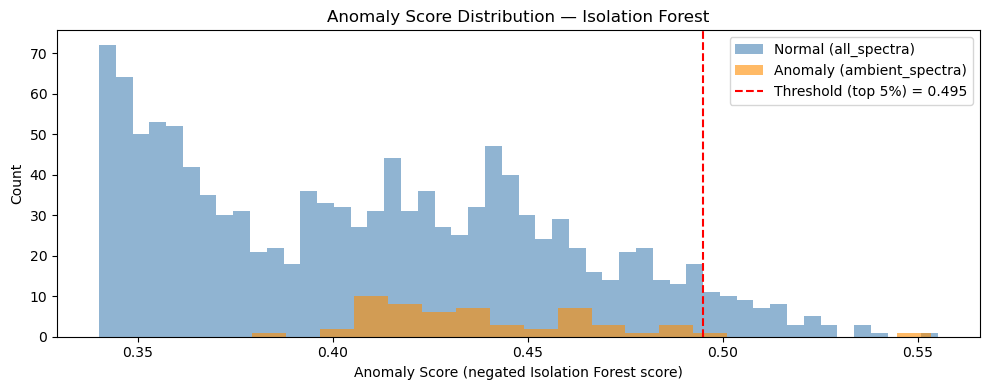

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

# Plot score distributions for both classes
ax.hist(scores_normal,  bins=50, alpha=0.6, color='steelblue',  label='Normal (all_spectra)')
ax.hist(scores_anomaly, bins=20, alpha=0.6, color='darkorange', label='Anomaly (ambient_spectra)')

# Draw the decision threshold
ax.axvline(threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold (top {THRESHOLD_PERCENTILE}%) = {threshold:.3f}')

ax.set_xlabel('Anomaly Score (negated Isolation Forest score)')
ax.set_ylabel('Count')
ax.set_title('Anomaly Score Distribution — Isolation Forest')
ax.legend()
plt.tight_layout()
plt.show()

**Results:** *(run the cell and interpret the plot here)*

## 8. Evaluate Performance

Predictions are made by comparing each sample's anomaly score against the threshold. Standard classification metrics are then used to measure performance.

- **Label convention:** `0` = normal, `1` = anomaly
- **Precision** — of all samples flagged as anomalies, how many actually were?
- **Recall** — of all actual anomalies, how many did the model catch?
- **F1** — harmonic mean of precision and recall
- **ROC-AUC** — overall ability to rank anomalies above normal samples (1.0 = perfect, 0.5 = random)

In [12]:
# Combine scores and true labels for evaluation
# 0 = normal, 1 = anomaly
all_scores = np.concatenate([scores_normal, scores_anomaly])
true_labels = np.concatenate([
    np.zeros(len(scores_normal)),   # normal samples labeled 0
    np.ones(len(scores_anomaly))    # anomaly samples labeled 1
])

# Predict: score above threshold → anomaly (1), otherwise normal (0)
pred_labels = (all_scores > threshold).astype(int)

# Compute ROC-AUC using raw scores (threshold-independent)
roc_auc = roc_auc_score(true_labels, all_scores)

print(f'ROC-AUC Score : {roc_auc:.4f}\n')
print('Classification Report:')
print(classification_report(true_labels, pred_labels, target_names=['Normal', 'Anomaly']))

ROC-AUC Score : 0.6839

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.95      0.95      1215
     Anomaly       0.03      0.04      0.03        55

    accuracy                           0.91      1270
   macro avg       0.49      0.49      0.49      1270
weighted avg       0.92      0.91      0.91      1270



**Results:** *(run the cell and interpret the output here)*

## 9. Confusion Matrix

The confusion matrix breaks down predictions into correct and incorrect categories:

|  | Predicted Normal | Predicted Anomaly |
|--|--|--|
| **Actually Normal** | True Negative (TN) | False Positive (FP) |
| **Actually Anomaly** | False Negative (FN) | True Positive (TP) |

For anomaly detection, **False Negatives (FN)** are the most costly — these are real anomalies the model missed.

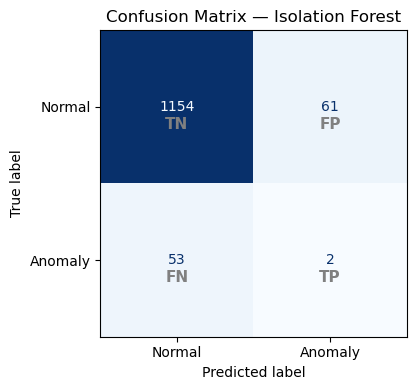

In [13]:
# Compute and display the confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Isolation Forest')

# Label each cell with TP, TN, FP, FN
labels = [['TN', 'FP'],
          ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'\n\n{labels[i][j]}', ha='center', va='center',
                fontsize=11, fontweight='bold', color='gray')

plt.tight_layout()
plt.show()

**Results:** *(run the cell and interpret the confusion matrix here)*

## 10. ROC Curve

The ROC curve plots the **True Positive Rate** (anomalies correctly caught) against the **False Positive Rate** (normal samples incorrectly flagged) across all possible thresholds.

- A curve hugging the top-left corner = excellent model
- A diagonal line = random guessing (AUC = 0.5)

This is useful because it shows performance independent of the threshold you chose.

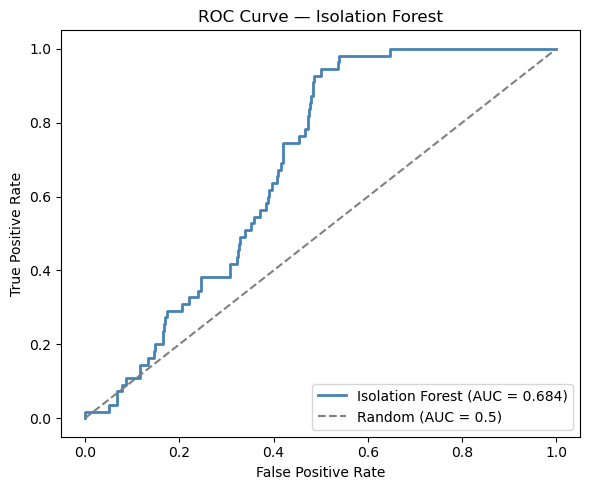

In [14]:
# Compute the ROC curve across all thresholds
fpr, tpr, _ = roc_curve(true_labels, all_scores)

fig, ax = plt.subplots(figsize=(6, 5))

# Plot the Isolation Forest ROC curve
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Isolation Forest (AUC = {roc_auc:.3f})')

# Plot the random baseline
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Isolation Forest')
ax.legend()
plt.tight_layout()
plt.show()

**Results:** *(run the cell and interpret the ROC curve here)*